---
title: Building Sentinel-2 Data Cubes with xcube EOPF Data Store
subtitle: Learn how to build analysis-ready data cubes from multiple EOPF Sentinel-2 Zarr samples.
authors:
  - name: Konstantin Ntokas
    orcid: 0000-0002-0049-0690
    github: konstntokas
    affiliations:
      - id: Brockmann Consult GmbH
        institution: Brockmann Consult GmbH
        ror: 04r0k9g65
reviewers:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2026-03-27
thumbnail: ../static/EOPF-on-bright-baseline.png
keywords: ["data access", "xarray", "EOPF Zarr products"]
tags: ["sentinel-2", "xcube", "land"]
releaseDate: 2026-03-27
datePublished: 2026-03-27
dateModified: 2026-03-27
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of Contents
1. [Introduction](#Introduction_XCUBE_EOPF_SEN2)
2. [Main Features of the xcube-eopf Data Store for Sentinel-2](#Main_Features_XCUBE_EOPF_SEN2)
3. [Import modules](#Import_XCUBE_EOPF_SEN2)
4. [Access Sentinel-2 Level-2A ARDC](#Access_L2A_XCUBE_EOPF_SEN2)
5. [Access Sentinel-2 Level-1C ARDC](#Access_L1C_XCUBE_EOPF_SEN2)
6. [Conclusion](#Conclusion_XCUBE_EOPF_SEN2)

(Introduction_XCUBE_EOPF_SEN2)=
## Introduction

`xcube-eopf` is a Python package that extends [xcube](https://xcube.readthedocs.io/en/latest) with a new [data store](https://xcube.readthedocs.io/en/latest/dataaccess.html#available-data-stores) called `"eopf-zarr"`. This plugin enables the creation of analysis-ready data cubes (ARDC) from multiple Sentinel products published by the [EOPF Sentinel Zarr Sample Service](https://zarr.eopf.copernicus.eu/).

In this notebook, we demonstrate how to use the **xcube EOPF data store** to access multiple **Sentinel-2** EOPF Zarr products and generate 3D analysis-ready data cubes (ARDC).

For a general introduction to the xcube EOPF Data Store, see the [introduction notebook](https://eopf-sample-service.github.io/xcube-eopf/examples/introduction/).  

- 🐙 **GitHub:** [EOPF Sample Service – xcube-eopf](https://github.com/EOPF-Sample-Service/xcube-eopf)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xcube-eopf/issues)  
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xcube-eopf/)

:::{hint} Overview
**Questions**
- How can the xcube-eopf data store be used to access Sentinel-2 products?
- What are the key features of the xcube-eopf data store for working with Sentinel-2 data?

**Objectives**
- Learn how to open and combine multiple EOPF Sentinel-2 Zarr datasets into analysis-ready data cubes (ARDCs).
- Understand the core features and capabilities of the xcube EOPF data store for Sentinel-2 workflows.
:::

---

(Main_Features_XCUBE_EOPF_SEN2)=
## Main Features of the xcube-eopf Data Store for Sentinel-2

Sentinel-2 provides multi-spectral imagery at different native spatial resolutions:

- **10 m:** B02, B03, B04, B08  
- **20 m:** B05, B06, B07, B8A, B11, B12  
- **60 m:** B01, B09, B10  

Sentinel-2 products are organized as STAC Items, each representing a single tile stored in its native UTM coordinate reference system (CRS).

![Sentinel-2 Tiles](sen2_tiles.png)


### Data Cube Generation Workflow

1. **STAC Query:** Relevant STAC Items (tiles) are retrieved via the STAC API based on the specified spatial and temporal extent (`bbox` and `time_range`).
2. **Sorting:** Items are ordered by acquisition time and tile ID.
3. **Native Alignment:** Within each UTM zone, tiles from the same acquisition day are aligned in their native CRS without reprojection. Overlapping pixels are resolved by selecting the first non-NaN value according to item order.
4. **Cube Assembly:** The cube generation strategy depends on the request, as summarized below:

| Scenario         | Native Resolution Preservation                                                                                                                                                                                                 | Reprojected or Resampled Cube                                                                                                                                                     |
|------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Condition**    | Bounding box lies within a single UTM zone, the native CRS is requested, and the spatial resolution matches the native resolution.                                                                                           | Data spans multiple UTM zones, a different CRS is requested (e.g., EPSG:4326), or a custom spatial resolution is specified.                                                     |
| **Processing**   | Only upsampling or downsampling is applied to align spectral bands with different resolutions. The cube is cropped to the requested bounding box, preserving original pixel values. The spatial extent may slightly adjust to the native grid. | A target grid is defined based on the bounding box, spatial resolution, and CRS. Data from each UTM zone is reprojected/resampled to this grid. Overlaps are resolved using the first non-NaN values. |


Users can specify any spatial resolution and coordinate reference system (CRS) when calling `open_data`. Depending on the request, spectral bands may be resampled (upsampled or downsampled) and/or reprojected to match the target grid using [xcube-resampling](https://github.com/xcube-dev/xcube-resampling).

📚 **More info:** [xcube-eopf Sentinel-2 Documentation](https://eopf-sample-service.github.io/xcube-eopf/guide/#sentinel-2)

---

(Import_XCUBE_EOPF_SEN2)=
## Import Modules

The `xcube-eopf` data store is provided as a plugin for `xcube`. Once installed, it registers automatically, allowing you to import `xcube` just like any other [xcube data store](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-access):

In [1]:
import datetime

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from xcube.core.store import new_data_store
from xcube_resampling.utils import reproject_bbox

(Access_L2A_XCUBE_EOPF_SEN2)=
## Access Sentinel-2 Level-2A ARDC

In this section, we demonstrate the available features and options for opening and generating spatio-temporal data cubes from multiple Sentinel-2 tiles.  
To initialize an `eopf-zarr` data store, run the cell below:

In [2]:
store = new_data_store("eopf-zarr")

The data IDs point to [STAC collections](https://stac.browser.user.eopf.eodc.eu). In the following cell we can list the available data IDs.

In [3]:
store.list_data_ids()

['sentinel-2-l1c',
 'sentinel-2-l2a',
 'sentinel-3-olci-l1-efr',
 'sentinel-3-olci-l2-lfr',
 'sentinel-3-slstr-l1-rbt',
 'sentinel-3-slstr-l2-lst']

Below, you can explore the parameters of the `open_data()` method for each supported data product. The following cell generates a JSON schema listing all available opening parameters for Sentinel-2 Level-2A products.

In [4]:
store.get_open_data_params_schema(data_id="sentinel-2-l2a")

### Spatio-Temporal Selection and Reprojection

We now generate a data cube from the Sentinel-2 L2A product by setting `data_id` to `"sentinel-2-l2a"`.  
The bounding box is defined to cover **Mount Etna in Sicily**, and the time range is set to the last 10 days.  
We begin by creating the data cube in its **native UTM projection** to avoid any reprojection or sub-pixel resampling.

In [5]:
time_range = [str(datetime.date.today() - datetime.timedelta(days=10)), None]
bbox = [14.8, 37.45, 15.3, 37.85]
crs_utm = "EPSG:32633"
bbox_utm = reproject_bbox(bbox, "EPSG:4326", crs_utm)

In [6]:
%%time
ds = store.open_data(
    data_id="sentinel-2-l2a",
    bbox=bbox_utm,
    time_range=time_range,
    spatial_res=20,
    crs=crs_utm,
    variables=["b02", "b03", "b04", "scl"],
)
ds

CPU times: user 2.01 s, sys: 101 ms, total: 2.11 s
Wall time: 21.3 s


<xarray.Dataset> Size: 614MB
Dimensions:      (time: 5, y: 2222, x: 2212)
Coordinates:
  * time         (time) datetime64[s] 40B 2026-03-22T09:50:31 ... 2026-03-31T...
  * y            (y) float64 18kB 4.189e+06 4.189e+06 ... 4.145e+06 4.145e+06
  * x            (x) float64 18kB 4.823e+05 4.823e+05 ... 5.265e+05 5.265e+05
    spatial_ref  int64 8B ...
Data variables:
    b02          (time, y, x) float64 197MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 197MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 197MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    scl          (time, y, x) uint8 25MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
Attributes: (5)

Note that the 3D datacube generation is fully **lazy**. Actual data download and processing (e.g., mosaicking, stacking) are performed **on demand** and are only triggered when the data is written or visualized.  

As an example, the next cell plots a single timestamp of the **red band** and the **Scene Classification Layer (SCL)**. The plot uses the color map information provided in the attributes of the SCL data array.

/home/konstantin/micromamba/envs/xcube-eopf/lib/python3.13/site-packages/numpy/_core/numeric.py:475: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
/home/konstantin/micromamba/envs/xcube-eopf/lib/python3.13/site-packages/dask/array/chunk.py:288: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


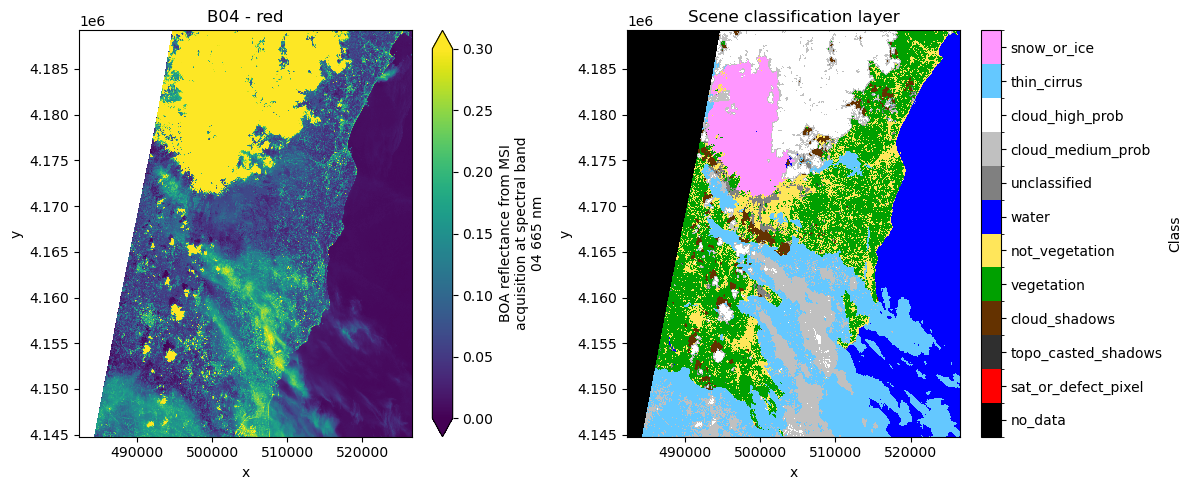

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ds.b04.isel(time=-2).plot(ax=ax[0], vmin=0.0, vmax=0.3)
ax[0].set_title("B04 - red")

cmap = mcolors.ListedColormap(ds.scl.attrs["flag_colors"].split(" "))
nb_colors = len(ds.scl.attrs["flag_values"])
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(nb_colors + 1) - 0.5, ncolors=nb_colors
)
im = ds.scl.isel(time=-2).plot.imshow(
    ax=ax[1], cmap=cmap, norm=norm, add_colorbar=False
)
cbar = fig.colorbar(im, ax=ax[1], ticks=ds.scl.attrs["flag_values"])
cbar.ax.set_yticklabels(ds.scl.attrs["flag_meanings"].split(" "))
cbar.set_label("Class")
ax[1].set_title("Scene classification layer")

plt.tight_layout()

The user can also set `crs="native"` which allows specifying the bounding box in latitude/longitude, but returns the data in UTM. Note if the data request covers multiple UTM zones, an error will be raised. 

In [8]:
ds = store.open_data(
    data_id="sentinel-2-l2a",
    bbox=bbox,
    time_range=time_range,
    spatial_res=10,
    crs="native",
    variables=["b02", "b03", "b04", "scl"],
)
ds

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 5, y: 4443, x: 4423)
Coordinates:
  * time         (time) datetime64[s] 40B 2026-03-22T09:50:31 ... 2026-03-31T...
  * y            (y) float64 36kB 4.189e+06 4.189e+06 ... 4.145e+06 4.145e+06
  * x            (x) float64 35kB 4.823e+05 4.823e+05 ... 5.265e+05 5.265e+05
    spatial_ref  int64 8B ...
Data variables:
    b02          (time, y, x) float64 786MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 786MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 786MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    scl          (time, y, x) uint8 98MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
Attributes: (5)

We can request the same data cube but in geographic projection ("EPSG:4326") as well. The xcube EOPF data store can reproject the datacube to any projection requested by the user.

In [9]:
ds = store.open_data(
    data_id="sentinel-2-l2a",
    bbox=bbox,
    time_range=time_range,
    spatial_res=20 / 111320,  # meters converted to degrees (approx.)
    crs="EPSG:4326",
    variables=["b02", "b03", "b04", "scl"],
)
ds

<xarray.Dataset> Size: 775MB
Dimensions:      (time: 5, lon: 2783, lat: 2227)
Coordinates:
  * time         (time) datetime64[s] 40B 2026-03-22T09:50:31 ... 2026-03-31T...
  * lon          (lon) float64 22kB 14.8 14.8 14.8 14.8 ... 15.3 15.3 15.3 15.3
  * lat          (lat) float64 18kB 37.85 37.85 37.85 ... 37.45 37.45 37.45
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    scl          (time, lat, lon) uint8 31MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
Attributes: (5)

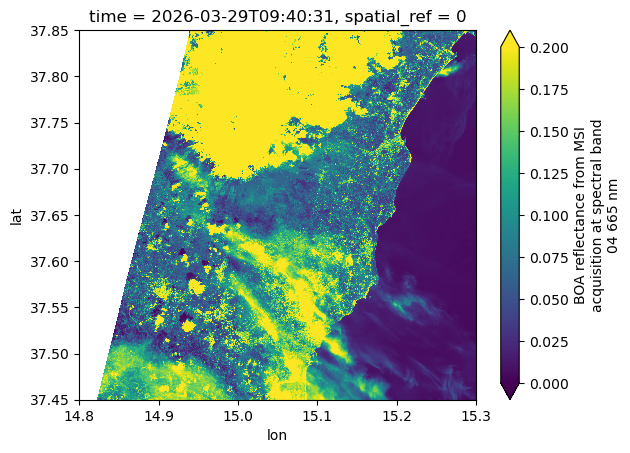

In [10]:
ds.b04.isel(time=-2).plot(vmin=0, vmax=0.2)

### Support for Common Band Names

Support has been added for **common band names** from the [STAC EO extension](https://github.com/stac-extensions/eo?tab=readme-ov-file#common-band-names) in **Sentinel-2 analysis mode**.  

The `variables` parameter now accepts standard spectral names such as `blue`, `green`, `red`, `nir`, and others.

The next cell demonstrates an example where we filter spectral bands using these common names.

In [11]:
ds = store.open_data(
    data_id="sentinel-2-l2a",
    bbox=bbox,
    time_range=time_range,
    spatial_res=20 / 111320,  # meters converted to degrees (approx.)
    crs="EPSG:4326",
    variables=["blue", "green", "red", "scl"],
)
ds

<xarray.Dataset> Size: 775MB
Dimensions:      (time: 5, lon: 2783, lat: 2227)
Coordinates:
  * time         (time) datetime64[s] 40B 2026-03-22T09:50:31 ... 2026-03-31T...
  * lon          (lon) float64 22kB 14.8 14.8 14.8 14.8 ... 15.3 15.3 15.3 15.3
  * lat          (lat) float64 18kB 37.85 37.85 37.85 ... 37.45 37.45 37.45
    spatial_ref  int64 8B 0
Data variables:
    blue         (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    green        (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    red          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    scl          (time, lat, lon) uint8 31MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
Attributes: (5)

(Access_L1C_XCUBE_EOPF_SEN2)=
## Access Sentinel-2 Level-1C ARDC

In this section, we demonstrate how to open and generate spatio-temporal data cubes from multiple Sentinel-2 **Level-1C** tiles.  

The Level-1C collection uses the same opening parameters as the Level-2A collection, as shown below.

In [12]:
store.get_open_data_params_schema(data_id="sentinel-2-l1c")

We set `data_id` to `"sentinel-2-l1c"` and leave `variables` unspecified, so **all spectral bands** are retrieved. We also do not set a `crs`, so the default `"EPSG:4326"` is used.

In [13]:
ds = store.open_data(
    data_id="sentinel-2-l1c",
    bbox=bbox,
    time_range=time_range,
    spatial_res=20 / 111320,  # meters converted to degrees (approx.)
)
ds

<xarray.Dataset> Size: 3GB
Dimensions:      (time: 5, lon: 2783, lat: 2227)
Coordinates:
  * time         (time) datetime64[s] 40B 2026-03-22T09:50:31 ... 2026-03-31T...
  * lon          (lon) float64 22kB 14.8 14.8 14.8 14.8 ... 15.3 15.3 15.3 15.3
  * lat          (lat) float64 18kB 37.85 37.85 37.85 ... 37.45 37.45 37.45
    spatial_ref  int64 8B 0
Data variables: (12/13)
    b02          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b05          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b06          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    ...           ...
    b11          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b12          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b8a          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b01          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b09          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b10          (time, lat, lon) float64 248MB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
Attributes: (5)

And we can plot a spectral band for a time stamp, which triggers loading the data for this slice.

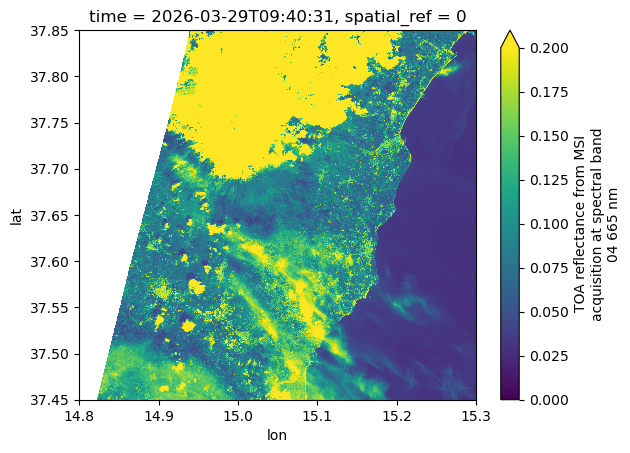

In [14]:
ds.b04.isel(time=-2).plot(vmin=0, vmax=0.2)

---

(Conclusion_XCUBE_EOPF_SEN2)=
## Conclusion

This notebook highlighted the main features of the **xcube EOPF Data Store** for Sentinel-2, which enables seamless access to multiple EOPF Zarr products as **analysis-ready data cubes (ARDCs)**. 

Key takeaways:

- **3D spatio-temporal data cubes** can be generated from multiple EOPF Sentinel Zarr samples.  
- Supports access to both **Sentinel-2 Level-2A** and **Level-1C** collections.  
- Data cubes can be requested with any **CRS**, spatial extent, temporal range, and spatial resolution.  
- Setting `crs="native"` preserves the **original UTM grid**; an error is raised if the requested spatial extent spans multiple UTM zones.  
- Common spectral bands, as defined by the [STAC EO extension](https://github.com/stac-extensions/eo?tab=readme-ov-file#common-band-names), are supported for variable selection.

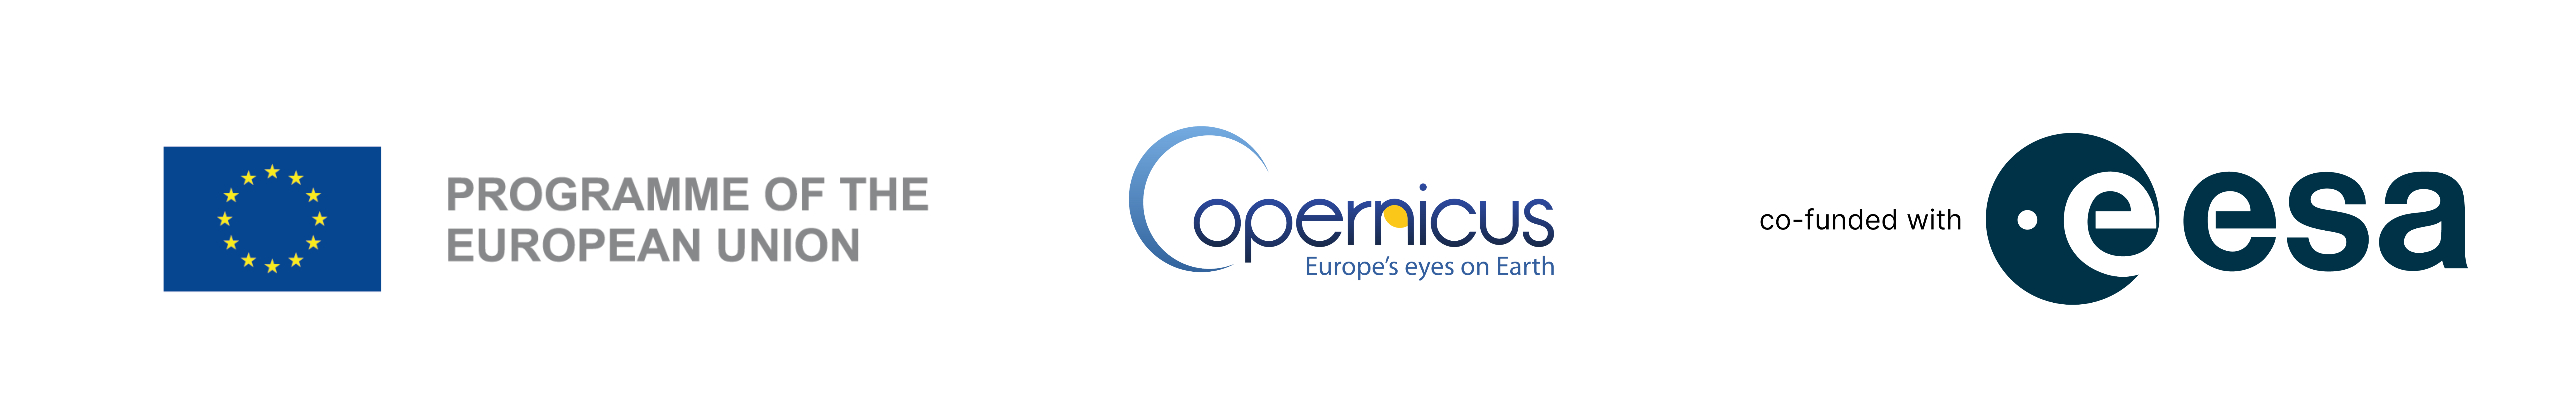